# Softmax Regression
> <span style='color:orange'>drug_class.csv</span>

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

In [4]:
df = pd.read_csv('drug_class.csv')
df.head()

,Age,Gender,BloodPressure,Cholestrol,Na_to_K,Class
0,23,M,LOW,HIGH,7.301033,drugC
1,69,M,LOW,HIGH,15.478000,drugY
2,74,M,HIGH,HIGH,9.516477,drugB
3,60,M,HIGH,NORMAL,8.742942,drugB
4,39,F,NORMAL,NORMAL,9.715872,drugX


In [5]:
# encoding the categorical classes
encoder = LabelEncoder()
df['Gender'] = encoder.fit_transform(df['Gender'])
df['BloodPressure'] = encoder.fit_transform(df['BloodPressure'])
df['Cholestrol'] = encoder.fit_transform(df['Cholestrol'])
df['Class'] = encoder.fit_transform(df['Class'])

In [38]:
df.head()

,Age,Gender,BloodPressure,Cholestrol,Na_to_K,Class
0,23,1,1,0,7.301033,2
1,69,1,1,0,15.478000,4
2,74,1,0,0,9.516477,1
3,60,1,0,1,8.742942,1
4,39,0,2,1,9.715872,3


In [7]:
# features and target
x = df.iloc[:, 0:5]
y = df.iloc[:,-1]

# data split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [23]:
# model train
lr = LogisticRegression(multi_class='multinomial') 
lr.fit(x_train, y_train)
y_Pred = lr.predict(x_test)

/Users/lucifer/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/lucifer/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [24]:
print('intercept: ',lr.intercept_)
print('coef: ',lr.coef_)

intercept:  [ 2.85274626 -1.39658672  2.2505926   0.44857877 -4.1553309 ]
coef:  [[-0.0372156   0.42408938 -3.86989075 -0.52194201  0.09492333]
 [ 0.14327464 -1.42135462 -4.23967639 -0.27788961 -0.23078387]
 [-0.02384702  0.57364232  1.72451755 -2.59867637 -0.04957417]
 [-0.02374391  0.10864551  4.74541004  3.35483327 -0.32987719]
 [-0.0584681   0.31497741  1.63963956  0.04367472  0.5153119 ]]


In [29]:
# evaluation
print('accuracy_score:',accuracy_score(y_test, y_Pred))
print('precision_score:',precision_score(y_test, y_Pred, average = 'weighted'))
print('recall_score:',recall_score(y_test, y_Pred, average = 'weighted'))
print('f1_score:',f1_score(y_test, y_Pred, average='weighted'))

accuracy_score: 0.9340659340659341
precision_score: 0.9380381523238666
recall_score: 0.9340659340659341
f1_score: 0.9347487015088699


In [31]:
# classification report
print(classification_report(y_test, y_Pred))

              precision    recall  f1-score   support

           0       0.86      0.95      0.90        19
           1       0.83      0.91      0.87        11
           2       1.00      0.94      0.97        16
           3       1.00      1.00      1.00        21
           4       0.95      0.88      0.91        24

    accuracy                           0.93        91
   macro avg       0.93      0.93      0.93        91
weighted avg       0.94      0.93      0.93        91



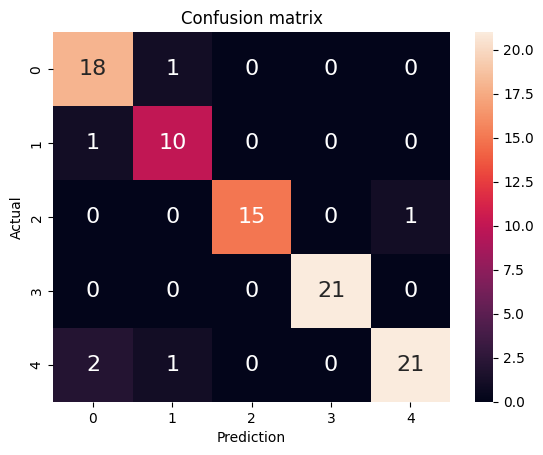

In [37]:
# confusion matrix
sns.heatmap(confusion_matrix(y_test, y_Pred), annot = True, annot_kws={"size": 16})
plt.title('Confusion matrix')
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.show()

In [39]:
# user input
user_ip = np.array([[23,1,1,0,7.301033]])

In [42]:
# probability of each drug class
lr.predict_proba(user_ip)

/Users/lucifer/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([[9.35183100e-03, 8.58019215e-05, 7.57388333e-01, 2.08435139e-01,
        2.47388945e-02]])

In [ ]:
print(lr.predict(user_ip))
print(encoder.inverse_transform(lr.predict(user_ip))) # decoding the class.

[2]
['drugC']


/Users/lucifer/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/lucifer/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


## PCA
- <span style = 'color:orange'>Decision Boundry</span>
- <span style = 'color:orange'>ROC curve</span>

In [45]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2) 
x_pca = pca.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(x_pca, y, test_size=0.2, random_state=42)

sr = LogisticRegression(max_iter=1000)
sr.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [56]:
components = pd.DataFrame(
    pca.components_,
    columns=x.columns,
    index=['PC1', 'PC2']
)

components.T

,PC1,PC2
Age,0.999595,0.028093
Gender,0.003399,-0.013083
BloodPressure,-0.003334,-0.003680
Cholestrol,0.000098,0.006602
Na_to_K,-0.028064,0.999491


> the first principal component is almost entirely determined by Age.

> second principal component is almost entirely determined by Na_to_K.

## Decision Boundry

/Users/lucifer/Library/Python/3.9/lib/python/site-packages/mlxtend/plotting/decision_regions.py:346: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


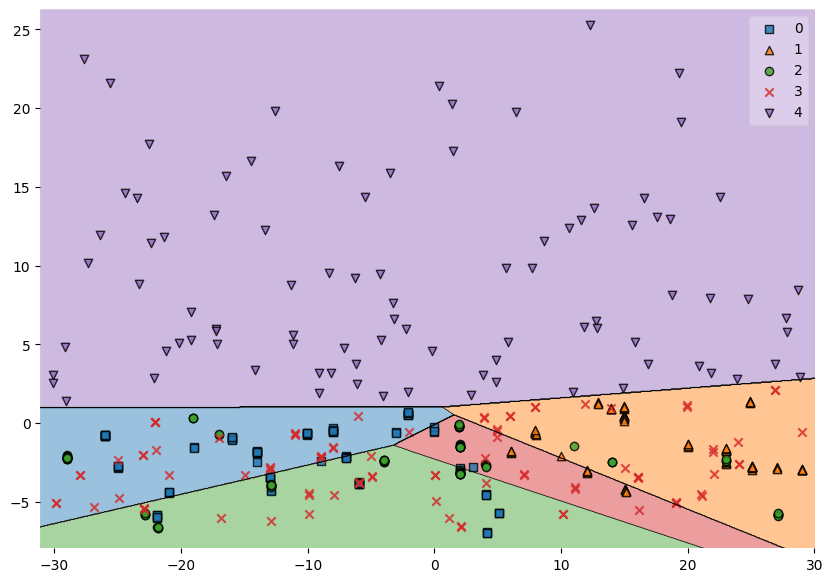

In [57]:
from mlxtend.plotting import plot_decision_regions
plt.figure(figsize=(10,7))
plot_decision_regions(x_pca, y.values, clf=sr, legend=1)
plt.show()

## ROC curve (One-VS-Rest)

Class 0
Best Threshold : 0.285
TPR            : 0.842
FPR            : 0.139
----------------------------------------
Class 1
Best Threshold : 0.205
TPR            : 1.000
FPR            : 0.125
----------------------------------------
Class 2
Best Threshold : 0.083
TPR            : 1.000
FPR            : 0.547
----------------------------------------
Class 3
Best Threshold : 0.206
TPR            : 0.857
FPR            : 0.486
----------------------------------------
Class 4
Best Threshold : 0.757
TPR            : 1.000
FPR            : 0.000
----------------------------------------


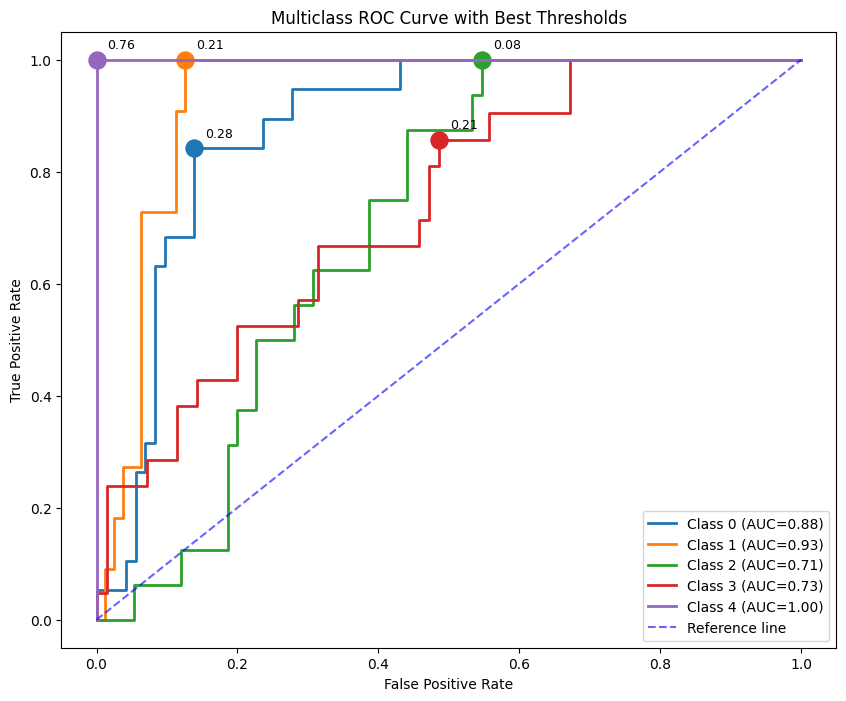

In [81]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Predicted probabilities
y_score = sr.predict_proba(x_test)

# Binarize true labels
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(10,8))

for i in range(len(classes)):

    # ROC
    fpr, tpr, thresholds = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    # Best threshold (Youden's J statistic)
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]

    # Plot ROC curve
    plt.plot(fpr, tpr,
             lw=2,
             label=f'Class {classes[i]} (AUC={roc_auc:.2f})')

    # Mark best threshold
    plt.scatter(fpr[optimal_idx],
                tpr[optimal_idx],
                s=150,
                marker='o',
                )

    # Annotate threshold
    plt.annotate(
        f'{optimal_threshold:.2f}',
        (fpr[optimal_idx], tpr[optimal_idx]),
        textcoords='offset points',
        xytext=(8,8),
        fontsize=9
    )

    print(f'Class {classes[i]}')
    print(f'Best Threshold : {optimal_threshold:.3f}')
    print(f'TPR            : {tpr[optimal_idx]:.3f}')
    print(f'FPR            : {fpr[optimal_idx]:.3f}')
    print('-'*40)

# Reference line

plt.plot([0,1], [0,1], 'blue', label='Reference line', alpha = 0.6, ls = 'dashed')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve with Best Thresholds')
plt.legend()
plt.show()